# optiver-close — Phase 3 on Colab

Reproduces Phase 3 from nothing but the repo and a Kaggle account: clone → download the
competition data → build the fixture → **verify the rebuild against the committed
manifest** → run the test suite → run the Phase 3 script on the GPU → read the numbers →
set them beside the published competition results.

Phase 3 puts a second model class beside Phase 2's on the same 31 columns and the same
folds, and asks what a blend of the two is worth. The arms:

| arm | what it is |
|---|---|
| `zero` | the floor, recomputed — must agree with Phases 1 and 2 to the digit |
| `lgbm_mem` | Phase 2's headline, rerun unchanged — same check, against `phase2_lgbm.json` |
| `mlp_mem` | **new**: an MLP with an 8-dimensional `stock_id` embedding, L1 loss, hyperparameters fixed a priori, early-stopped on an inner holdout carved from the *training* dates |
| `blend_fixed` | 0.5 · `lgbm_mem` + 0.5 · `mlp_mem` — fits nothing |
| `blend_forward` | **the headline, named before the run**: per-fold weight fitted on the out-of-fold predictions of *earlier* folds only; fold 0 takes the 0.5 prior |

The forward weight is the point of discipline here. One scalar fitted on the pooled
out-of-fold predictions and then scored on them is a leak the fold loop cannot see — small,
and refused for exactly that reason (`ensemble.py`). `+` is better throughout: the number
is how far below predict-zero an arm lands.

**SMOKE numbers are never results.** The committed 40-stock fixture exists so the tests are
green on a fresh clone; this notebook runs the **FULL** preset, and only FULL numbers go in
the log.

**Runtime:** pick a **GPU** runtime (Runtime → Change runtime type; an A100 is the expected
path) and **high-RAM** if offered. `run_phase3.py` runs the LightGBM arm and the MLP arm
as two parallel subprocesses — trees on the CPU's 8 pinned threads, the network on the
GPU, at the same time — so peak memory is roughly two fixtures' worth. The script records
its own `runtime_seconds`; read that field rather than a number typed here. Without a GPU
the run is still valid, just slow, and §5 will say so loudly.

**You need:** a Kaggle account that has **joined** the *Optiver — Trading at the Close*
competition (kaggle.com/competitions/optiver-trading-at-the-close → Late Submission /
"I Understand and Accept"), and an API token (`kaggle.json` from kaggle.com → Settings →
Create New Token). Without having accepted the rules, the download in §2 returns a 403.

## 1. The repo

In [1]:
import os, subprocess
from pathlib import Path

REPO_USER = "Bromine185"
REPO_NAME = "optiver-close"
REPO = Path("/content") / REPO_NAME

if not REPO.exists():
    token = os.environ.get("GITHUB_TOKEN", "")   # empty string → no auth prefix
    auth  = f"{token}@" if token else ""
    url   = f"https://{auth}github.com/{REPO_USER}/{REPO_NAME}.git"
    subprocess.run(["git", "clone", "--depth", "1", "--branch", "master", url, str(REPO)], check=True)
    del auth, url
else:
    subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only"], check=False)

%cd {REPO}
!git log --oneline -1

/content/optiver-close
6986b36 (grafted, HEAD -> master, origin/master, origin/HEAD) Phase 3: MLP + forward-weighted blend, published-result benchmarks, Colab notebooks


In [2]:
# Colab ships numpy/pandas/pyarrow/scipy/sklearn/matplotlib, torch, and (usually)
# lightgbm. pytest is the usual gap; lightgbm is installed only if genuinely absent.
#
# torch is NEVER installed or upgraded here. Colab's build is matched to the VM's CUDA;
# a pip torch would replace it with one that may not see the GPU at all.
import importlib, subprocess, sys

for module, package in [("pytest", "pytest>=8.0"), ("lightgbm", "lightgbm>=4.0")]:
    if importlib.util.find_spec(module) is None:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", package], check=True)

if importlib.util.find_spec("torch") is None:
    raise SystemExit("torch is missing — this is not a standard Colab runtime. Pick a GPU "
                     "runtime (Runtime → Change runtime type) rather than pip-installing torch.")

sys.path.insert(0, str(REPO / "src"))
import numpy as np, pandas as pd
import lightgbm, torch
print(f"python {sys.version.split()[0]}  numpy {np.__version__}  pandas {pd.__version__}  "
      f"lightgbm {lightgbm.__version__}  torch {torch.__version__}")

python 3.13.15  numpy 2.1.3  pandas 2.2.3  lightgbm 4.6.0  torch 2.11.0+cu128


## 2. The raw data, from Kaggle

`data/raw/` is gitignored (641 MB) and `data/fixtures/train.parquet` (130 MB) is too — what
the repo commits is `manifest.json`, the record a rebuild is checked against, plus the 4 MB
smoke fixture the tests run on. So Colab downloads the competition zip once and rebuilds.

Provide the API token one of two ways:
- **Colab secret** (better): key icon in the left sidebar → add `KAGGLE_USERNAME` and
  `KAGGLE_KEY` (the two fields inside your `kaggle.json`), grant this notebook access;
- **upload**: run the cell and pick your `kaggle.json` when asked.

In [4]:

import json as _json
import shutil

RAW = REPO / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)

if not (RAW / "train.csv").exists():
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-U", "kagglehub"], check=True)
    import kagglehub

    try:
        src = Path(kagglehub.competition_download("optiver-trading-at-the-close"))
    except Exception as e:
        if "403" in str(e) or "Forbidden" in str(e):
            raise SystemExit(
                "403: this Kaggle account has not accepted the competition rules — "
                "visit kaggle.com/competitions/optiver-trading-at-the-close and join first."
            ) from e
        # no credentials found anywhere: interactive login (username + API token, no file)
        kagglehub.login()
        src = Path(kagglehub.competition_download("optiver-trading-at-the-close"))

    # kagglehub caches the files already unzipped; link them into data/raw/ where
    # scripts/build_fixture.py expects them (no 641 MB copy).
    for item in src.iterdir():
        dest = RAW / item.name
        if not dest.exists():
            dest.symlink_to(item)

print(f"train.csv: {(RAW / 'train.csv').stat().st_size / 1e6:.0f} MB")

100%|██████████| 201M/201M [00:02<00:00, 84.5MB/s]


Extracting files...
train.csv: 641 MB


## 3. Build the fixture, and check the rebuild against the committed manifest

`scripts/build_fixture.py` is the one place `train.csv` is ever read (CLAUDE.md
non-negotiable #2). It downcasts with a measured precision gate, refuses to fill nulls, and
writes `manifest.json` — row counts, dtypes, per-column null counts, coverage, the gate's
numbers, and the parquet's sha256.

The build **overwrites** the committed manifest, which is exactly what makes verification
easy: `git diff` afterwards is the reproduction report. Two classes of difference are
expected and harmless — timestamps/`build_seconds`/`versions`, and the parquet `sha256`/
`bytes` if Colab's pandas/pyarrow differ from the versions recorded (zstd bytes are
version-sensitive; the *content* checks are everything else). **Any other diff — a row
count, a null count, a coverage number, the precision gate — means the rebuild did not
reproduce the fixture, and nothing downstream of it should be trusted.**

In [5]:
!python scripts/build_fixture.py

reading /content/optiver-close/data/raw/train.csv (641 MB) in chunks of 1,000,000
  chunk 0: 1,000,000 rows
  chunk 1: 2,000,000 rows
  chunk 2: 3,000,000 rows
  chunk 3: 4,000,000 rows
  chunk 4: 5,000,000 rows
  chunk 5: 5,237,980 rows
  parsed in 13s

wrote data/fixtures/train.parquet  (131.0 MB, 5,237,980 rows)
wrote data/fixtures/train_smoke.parquet  (4.2 MB, 140,360 rows, 40 stocks x 64 dates)
wrote data/fixtures/manifest.json

target float32 gate: max |err| = 1.47e-05 bps (tol 0.001), zero-MAE shift = 2.5e-10 bps (tol 1e-06) -> ACCEPTED
zero-predictor MAE over the whole fixture: 6.407771 bps
stock-days missing: 964 of 96,200; partial auctions: 0
null targets: 88 (kept in the fixture, not dropped)


In [ ]:
# The reproduction report: the rebuilt manifest against the committed one (git HEAD),
# compared STRUCTURALLY by optiver.manifest — ints/strings/bools exact, floats to 1e-9
# relative, build-time / library-version / zstd-byte keys ignored. Same check as
# `python scripts/check_manifest.py`; a text diff of the JSON is not (a different numpy
# reduces 5.2 M-row moments in a different order and moves the last digit of kurtosis).
from optiver import manifest as M

report = M.check(REPO)
print(report.summary())
if not report.ok:
    raise SystemExit("the rebuild did not reproduce the fixture; do not trust anything below this cell")

man = _json.loads((REPO / "data" / "fixtures" / "manifest.json").read_text())
print(f"rows {man['rows']:,}  build {man['build_seconds']}s")


## 4. The test suite

Everything through Phase 2 (split guarantees, target definition, null policy, feature
causality by truncation), plus Phase 3's: the MLP is bit-identical fit-to-fit on CPU, its
early-stopping holdout lies inside the training dates and is embargoed from them by
position, its predictions move only with the columns it was given, and the blend weight
for fold *k* is fitted on folds *< k* and nothing else. GPU runs are float-close rather
than bit-identical (see `neural.py`); the tests pin CPU. The benchmark file's schema is
checked here too.

In [8]:
!python -m pytest -q

........................................................................ [ 66%]
....................................                                     [100%]
=============================== warnings summary ===============================
tests/test_boosted.py::test_same_fit_twice_is_bit_identical
tests/test_boosted.py::test_same_fit_twice_is_bit_identical
tests/test_boosted.py::test_predictions_are_finite_and_not_constant
tests/test_boosted.py::test_column_subset_is_respected
tests/test_boosted.py::test_column_subset_is_respected
tests/test_boosted.py::test_lgbm_runs_inside_the_phase1_harness
tests/test_boosted.py::test_lgbm_runs_inside_the_phase1_harness
tests/test_boosted.py::test_lgbm_runs_inside_the_phase1_harness
  /usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
    warnings.warn(

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html


## 5. The GPU

The MLP's training is where the GPU is spent; everything else in the run is CPU. This cell
is the check that the runtime actually has one — a notebook that silently falls back to CPU
produces a valid number many times more slowly, which is the kind of surprise worth
catching before a 5-fold run rather than after.

In [9]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv 2>/dev/null || echo "(nvidia-smi not available)"

import torch
if torch.cuda.is_available():
    DEVICE = "cuda"
    print(f"\ntorch {torch.__version__}  cuda {torch.version.cuda}  device: {torch.cuda.get_device_name(0)}")
else:
    DEVICE = "cpu"
    print("\n" + "!" * 78)
    print("!! NO CUDA DEVICE. The run below will use the CPU: still valid, many times slower.")
    print("!! Runtime → Change runtime type → GPU (A100 if offered), then rerun from §1.")
    print("!" * 78)
print(f"DEVICE = {DEVICE!r}")

name, memory.total [MiB], driver_version
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07

torch 2.11.0+cu128  cuda 12.8  device: NVIDIA A100-SXM4-40GB
DEVICE = 'cuda'


## 6. Phase 3: the network, the trees, and the forward blend

`run_phase3.py` on the FULL preset. Flags: `--preset`, `--out`, `--device`, and `--serial`
(run the two arms one after the other instead of in parallel — only if the VM runs out of
memory). The LightGBM arm and the MLP arm are separate processes; each runs the same
`run_cv` on the same folds, and the parent process merges their out-of-fold vectors, checks
they are row-aligned, and computes the blends.

What the run prints, in order: the folds; MAE by fold for every arm, paired against zero;
the forward blend's per-fold weights (on `lgbm_mem`; fitted on earlier folds only, fold 0
is the prior); the pooled scorecard; the replica check against `phase2_lgbm.json`; the
consistency breakdowns; and where early stopping landed in each fold.

Success looks like: `zero` reproduces Phase 2 to ~1e-6 and `lgbm_mem` to float noise;
`mlp_mem` is finite on every scored row; and the blend's per-fold weights are fitted on
dates that all precede the fold they are applied to.

In [11]:
!python scripts/run_phase3.py --preset FULL --device {DEVICE}

=== Phase 3  preset FULL  fixture train.parquet  arms parallel ===
[lgbm] started pid 5612
[mlp] started pid 5613

----- [lgbm] child output -----
[lgbm] drop_null_targets: dropped 88 of 5237980 rows with a null target
[lgbm] Fold(0: train 0..175 [176d], gap 5, val 181..240 [60d])  train 1,890,649 rows / val 656,150 rows
[lgbm] /usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
[lgbm]   warnings.warn(
[lgbm] Fold(1: train 0..235 [236d], gap 5, val 241..300 [60d])  train 2,546,249 rows / val 657,030 rows
[lgbm] /usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
[lgbm]   warnings.warn(
[lgbm] Fold(2: train 0..295 [296d], gap 5, val 301..360 [60d])  train 3,203,004 rows / val 659,944 rows
[lgbm] /usr/local/lib/python3.13/dist-packages/sklearn/utils/va

## 7. Read the report

`reports/phase3_ensemble.json` — the file whose committed copy backs every Phase 3 number
in `RESEARCH.md`. Compare pooled numbers and within-fold *differences*; fold-to-fold MAE
swings by 1.3 bps on its own. A GPU run reproduces the committed copy to float noise, not
to the bit (`neural.py` says why); the `zero` and `lgbm_mem` replicas should match
exactly, since neither touches the GPU.

In [12]:
def report_diff(name: str) -> None:
    p = REPO / "reports" / name
    if not p.exists():
        print(f"{name}: not written (section skipped?)")
        return
    d = subprocess.run(["git", "diff", "--stat", "--", str(p.relative_to(REPO))],
                       capture_output=True, text=True).stdout.strip()
    print(f"{name}: {'matches the committed copy' if not d else d}")

report_diff("phase3_ensemble.json")

rep = _json.loads((REPO / "reports" / "phase3_ensemble.json").read_text())
print(f"\npreset {rep['preset']}   device {rep['device']}   torch {rep['torch_version']}   "
      f"runtime {rep['runtime_seconds']:.0f}s   headline {rep['headline']}")

print(f"\n{'arm':<16s} {'MAE bps':>9s} {'vs zero':>9s} {'%':>7s}")
for row in sorted(rep["scorecard"], key=lambda r: r["mae_bps"]):
    print(f"{row['model']:<16s} {row['mae_bps']:9.5f} {row['vs_zero_bps']:+9.5f} "
          f"{row['vs_zero_pct']:+6.2f}%")

ft = pd.DataFrame(rep["fold_table"]).set_index("model")
print("\nMAE by fold (bps), paired against zero within fold:")
print(ft.to_string(float_format=lambda x: f"{x:8.4f}"))

print("\nforward blend: weight on lgbm_mem (1 - w on mlp_mem), fitted on earlier folds only")
print(pd.DataFrame(rep["blend_weights"]).to_string(index=False))

rc = rep["replica_check"]
if rc.get("available"):
    print("\nreplica check against reports/phase2_lgbm.json:")
    for arm, r in rc["arms"].items():
        tol = 1e-6 if arm == "zero" else 1e-3
        flag = "agrees" if r["abs_diff"] <= tol else "WARNING: differs beyond float noise"
        print(f"  {arm:<10s} phase2 {r['phase2']:.5f}  phase3 {r['phase3']:.5f}  "
              f"|diff| {r['abs_diff']:.2e}  {flag}")
else:
    print(f"\nreplica check skipped: {rc.get('reason', 'no phase2 report')}")

print("\nmlp_mem early stopping, per fold:")
for i, s in enumerate(rep["mlp_training"]):
    best = s["history"][s["best_epoch"]]["inner_val_mae"]
    print(f"  fold {i}: best epoch {s['best_epoch']} of {s['epochs_run']} run on {s['device']}, "
          f"inner holdout dates {s['inner_val_dates'][0]}..{s['inner_val_dates'][1]} "
          f"({s['inner_val_dates'][2]}d), best inner MAE {best:.4f}")

for arm in ("blend_forward", "mlp_mem"):
    c = rep["consistency"][arm]
    for by in ("date_id", "stock_id"):
        print(f"\n{arm} by {by}: better than zero on {c[by]['share_of_groups_better']:.1%} of groups, "
              f"mean {c[by]['mean_improvement_bps']:+.4f} bps, worst {c[by]['worst_bps']:+.4f}, "
              f"best {c[by]['best_bps']:+.4f}")

phase3_ensemble.json: matches the committed copy

preset FULL   device cuda   torch 2.11.0+cu128   runtime 400s   headline blend_forward

arm                MAE bps   vs zero       %
blend_forward      6.25313  +0.13205  +2.07%
blend_fixed        6.25441  +0.13077  +2.05%
lgbm_mem           6.25639  +0.12879  +2.02%
mlp_mem            6.27146  +0.11372  +1.78%
zero               6.38518  +0.00000  +0.00%

MAE by fold (bps), paired against zero within fold:
                 fold0    fold1    fold2    fold3    fold4     mean      std  mean_vs_zero
model                                                                                     
blend_forward   6.9561   5.9277   6.3462   6.3343   5.7040   6.2537   0.3909        0.1321
blend_fixed     6.9561   5.9293   6.3482   6.3354   5.7057   6.2549   0.3904        0.1308
lgbm_mem        6.9616   5.9302   6.3479   6.3384   5.7066   6.2569   0.3918        0.1288
mlp_mem         6.9747   5.9473   6.3653   6.3513   5.7213   6.2720   0.3911        

## 8. Three pictures

(a) MAE through the auction, predict-zero against the headline blend. (b) The comparison
that survives the fold-to-fold swing: within each fold, the blend minus `lgbm_mem` and the
MLP minus `lgbm_mem`, in bps, `+` meaning the Phase 3 arm is better — five bars each, and
the question is whether they sit on one side of zero. (c) Each fold's inner-validation
curve with the epoch early stopping kept; the holdout these curves are scored on lies
inside the fold's training dates, so the fold's own validation block is untouched by them.

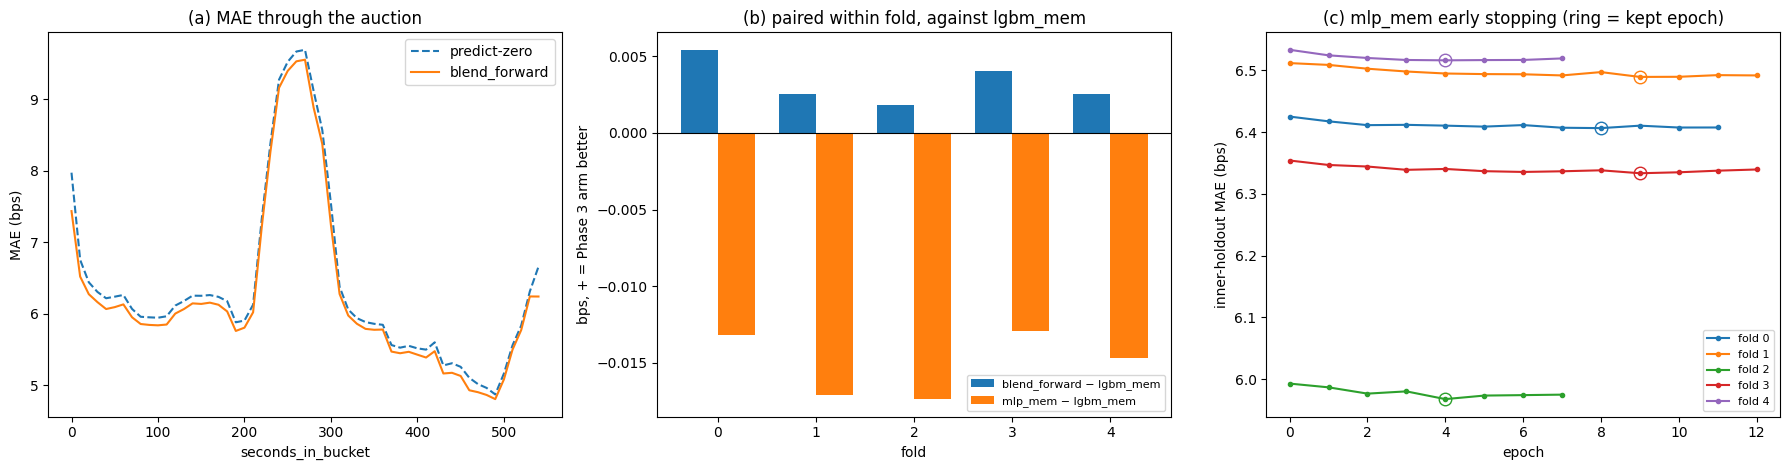

In [13]:
import matplotlib.pyplot as plt

bs = pd.DataFrame(rep["by_seconds"])
paired = rep["paired_by_fold"]
folds = np.arange(len(paired["blend_forward_minus_lgbm_mem"]))

fig, axes = plt.subplots(1, 3, figsize=(18, 4.8))

axes[0].plot(bs["seconds_in_bucket"], bs["mae_zero"], ls="--", label="predict-zero")
axes[0].plot(bs["seconds_in_bucket"], bs["mae"], label="blend_forward")
axes[0].set_xlabel("seconds_in_bucket"); axes[0].set_ylabel("MAE (bps)")
axes[0].set_title("(a) MAE through the auction"); axes[0].legend()

w = 0.38
axes[1].bar(folds - w / 2, paired["blend_forward_minus_lgbm_mem"], w, label="blend_forward − lgbm_mem")
axes[1].bar(folds + w / 2, paired["mlp_mem_minus_lgbm_mem"], w, label="mlp_mem − lgbm_mem")
axes[1].axhline(0, color="k", lw=0.8)
axes[1].set_xticks(folds); axes[1].set_xlabel("fold"); axes[1].set_ylabel("bps, + = Phase 3 arm better")
axes[1].set_title("(b) paired within fold, against lgbm_mem"); axes[1].legend(fontsize=8)

for i, s in enumerate(rep["mlp_training"]):
    h = pd.DataFrame(s["history"])
    line, = axes[2].plot(h["epoch"], h["inner_val_mae"], marker=".", label=f"fold {i}")
    axes[2].plot(s["best_epoch"], h["inner_val_mae"][s["best_epoch"]], marker="o", ms=9,
                 mfc="none", color=line.get_color())
axes[2].set_xlabel("epoch"); axes[2].set_ylabel("inner-holdout MAE (bps)")
axes[2].set_title("(c) mlp_mem early stopping (ring = kept epoch)"); axes[2].legend(fontsize=8)

plt.tight_layout(); plt.show()

## 9. Beside the published results

`scripts/compare_benchmarks.py` reads `reports/benchmarks.json` — the sourced public
numbers, each with its URL and which leaderboard it came from — together with the Phase 2
and Phase 3 reports, and writes `reports/benchmark_comparison.md`.

What is compared is **improvement over predict-zero**, not raw MAE. Raw MAE is not
comparable across periods: this repo's floor is 6.385 bps pooled over dates 181–480 and
swings 5.82–7.13 fold to fold, while an all-zeros submission scored ≈5.40 on the public
leaderboard — a different stretch of market. The rows from this repo are labelled as
offline purged CV and never as a leaderboard; `BENCHMARKS.md` carries the full argument
and, in the log's habit, what the comparison does *not* license anyone to say.

In [14]:
!python scripts/compare_benchmarks.py

=== benchmarks  11 published entries, 8 rows from this repo ===

                                                       entry                                       period   mae_bps  zero_mae_bps  improvement_bps  improvement_pct
                       LightGBM + MLP, weight fitted forward offline purged CV, dates 181..480 (this repo    6.2531        6.3852           0.1320           2.0681
                              0.5 LightGBM + 0.5 MLP (fixed) offline purged CV, dates 181..480 (this repo    6.2544        6.3852           0.1308           2.0480
                             LightGBM, 31 features (+memory) offline purged CV, dates 181..480 (this repo    6.2559        6.3852           0.1293           2.0244
                          MLP + stock embedding, 31 features offline purged CV, dates 181..480 (this repo    6.2715        6.3852           0.1137           1.7811
    1st place, mid-competition (2023-12): leaderboard leader public leaderboard (hidden dates after train    5.3070

In [15]:
from IPython.display import Markdown, display

display(Markdown((REPO / "reports" / "benchmark_comparison.md").read_text()))

# Benchmark comparison

Rendered by `python scripts/compare_benchmarks.py` from `reports/benchmarks.json` (retrieved 2026-09-04), `reports/phase2_lgbm.json` and `reports/phase3_ensemble.json`.

Improvement is over predict-zero **on the same rows**, and is the only column that
compares across periods. Rows with no published zero baseline for their period get
no improvement rather than a guessed one. Why MAE itself does not compare, and what
this table does not license anyone to say, is in `BENCHMARKS.md`.

| entry | period | MAE (bps) | zero MAE, same rows | improvement (bps) | improvement (%) | source |
|---|---|---:|---:|---:|---:|---|
| LightGBM + MLP, weight fitted forward | offline purged CV, dates 181..480 (this repo) | 6.2531 | 6.385 | 0.1320 | 2.07 | reports/phase3_ensemble.json (Phase 3, `blend_forward`) |
| 0.5 LightGBM + 0.5 MLP (fixed) | offline purged CV, dates 181..480 (this repo) | 6.2544 | 6.385 | 0.1308 | 2.05 | reports/phase3_ensemble.json (Phase 3, `blend_fixed`) |
| LightGBM, 31 features (+memory) | offline purged CV, dates 181..480 (this repo) | 6.2559 | 6.385 | 0.1293 | 2.02 | reports/phase2_lgbm.json (Phase 2, `lgbm_mem`) |
| MLP + stock embedding, 31 features | offline purged CV, dates 181..480 (this repo) | 6.2715 | 6.385 | 0.1137 | 1.78 | reports/phase3_ensemble.json (Phase 3, `mlp_mem`) |
| 1st place, mid-competition (2023-12): leaderboard leader | public leaderboard (hidden dates after train, scored to 2023-12-20) | 5.3070 | 5.400 | 0.0930 | 1.72 | https://medium.com/@joehbridges/gauging-the-market-optivers-trading-at-the-close-kaggle-competition-27b73f7789c0 (secondary) |
| LightGBM, 14 row-wise features | offline purged CV, dates 181..480 (this repo) | 6.2843 | 6.385 | 0.1009 | 1.58 | reports/phase2_lgbm.json (Phase 2, `lgbm_row`) |
| Open-source feature-engineering LightGBM (public notebooks, 2023-12) | public leaderboard (hidden dates after train, scored to 2023-12-20) | 5.3300 | 5.400 | 0.0700 | 1.30 | https://www.zhihu.com/en/article/678286556 (secondary) |
| 14th place: LightGBM + CatBoost, 193 features, zero-sum post-processing (public) | public leaderboard (hidden dates after train, scored to 2023-12-20) | 5.3327 | 5.400 | 0.0673 | 1.25 | https://www.zhihu.com/en/article/689096751 (secondary) |
| Single LightGBM, 5-fold purged K-fold by date_id, +/-2-date embargo (fan2goa1, public rank 186) | public leaderboard (hidden dates after train, scored to 2023-12-20) | 5.3341 | 5.400 | 0.0659 | 1.22 | https://fan2goa1.github.io/mkdocs-material/blog/2023/12/24/kaggle-optiver---trading-at-the-close/ (primary) |
| ridge, 31 features (+memory) | offline purged CV, dates 181..480 (this repo) | 6.3104 | 6.385 | 0.0748 | 1.17 | reports/phase2_lgbm.json (Phase 2, `ridge_mem`) |
| ConvNet on imbalance + raw features (nimashahbazi) | public leaderboard (hidden dates after train, scored to 2023-12-20) | 5.3439 | 5.400 | 0.0561 | 1.04 | https://github.com/nimashahbazi/optiver-trading-close (primary) |
| ridge, 14 row-wise features | offline purged CV, dates 181..480 (this repo) | 6.3224 | 6.385 | 0.0628 | 0.98 | reports/phase2_lgbm.json (Phase 2, `ridge`) |
| predict-zero (the floor) | offline purged CV, dates 181..480 (this repo) | 6.3852 | 6.385 | 0.0000 | 0.00 | reports/phase2_lgbm.json (Phase 2, `zero`) |
| 1st place (HYD): CatBoost 0.5 / GRU 0.3 / Transformer 0.2, online refit x5 | private leaderboard (forecasting period, 2024) | 5.4030 | — | — | — | https://www.modb.pro/db/1774620580892971008 (secondary) |
| 6th place: Transformer x3 + GRU, seq2seq, daily incremental refit | private leaderboard (forecasting period, 2024) | 5.4285 | — | — | — | https://www.modb.pro/db/1774620580892971008 (secondary) |
| 14th place: LightGBM + CatBoost, 193 features, zero-sum post-processing (private) | private leaderboard (forecasting period, 2024) | 5.4458 | — | — | — | https://www.zhihu.com/en/article/689096751 (secondary) |
| Forecasting-period leaderboard, first refresh (2024-01): gold zone | private leaderboard (forecasting period, 2024) | 5.4610 | — | — | — | https://www.zhihu.com/en/article/678286556 (secondary) |
| Forecasting-period leaderboard, first refresh (2024-01): open-source zone | private leaderboard (forecasting period, 2024) | 5.4640 | — | — | — | https://www.zhihu.com/en/article/678286556 (secondary) |
| LightGBM + Transformer 8:2 (study-session presenter's own solution, rank not stated) | private leaderboard (forecasting period, 2024) | 5.4820 | — | — | — | https://www.docswell.com/s/8980249862/K6YQ3E-2024-05-23-200638 (primary) |

## Not sourced

* The all-zeros score on the private (forecasting-period) leaderboard. Without it no private-leaderboard improvement can be computed, and none is.
* The final medal cutoffs and the number of teams.
* Any top solution's CV MAE together with a description of its CV split; the two CV numbers found (5.8117 for 1st place, 5.858 for the study-session LightGBM) come without one and are recorded in notes only.


## 10. Keep the results

Two files leave the VM: the Phase 3 report and the benchmark comparison. They are
**committed from the local machine, with the log entry that quotes them** — the repo's
policy is that a number enters `RESEARCH.md` beside the command that produced it, and that
happens in one commit, not in a push from Colab. Download both, drop them into `reports/`
in your clone, and commit them with the Phase 3 section of the log.

In [16]:
from google.colab import files

for name in ("phase3_ensemble.json", "benchmark_comparison.md"):
    files.download(str(REPO / "reports" / name))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

### What NOT to conclude from a green run

Whatever the blend's margin over `lgbm_mem` turns out to be, it is a measurement of two
untuned default configurations and one forward-fitted scalar — not what a neural model
"can do" here, and not what a tuned ensemble would do. Nothing here was scored through the
competition API, so nothing here is a leaderboard number; the comparison in §9 is between
improvements over the same floor on different periods, and `BENCHMARKS.md` says how far
that can be pushed. And the fold-to-fold swing is still 1.3 bps against a model effect
measured in hundredths: a Phase 3 arm that wins in 5 of 5 folds is a consistency
statement, and a pooled number on its own is not.